# Виды перекрестной проверки для данных формата «один клиент – одно наблюдение» (отсутствует ось времени)  

## Обычная нестратифицированная k-блочная перекрестная проверка с помощью класса KFold

In [1]:
# импортируем необходимые библиотеки
import numpy as np
import pandas as pd
# импортируем наборы
from sklearn import datasets
# импортируем функции train_test_split() и cross_val_score(),
# классы KFold, StratifiedKFold, RepeatedKFold,
# RepeatedStratifiedKFold, ShuffleSplit, StratifiedShuffleSplit,
# LeaveOneOut, LeavePOut, GroupKFold, LeaveOneGroupOut,
# LeavePGroupsOut, StratifiedGroupKFold, GroupShuffleSplit
from sklearn.model_selection import (train_test_split,
                                     cross_val_score,
                                     KFold,
                                     StratifiedKFold,
                                     RepeatedKFold,
                                     RepeatedStratifiedKFold,
                                     ShuffleSplit,
                                     StratifiedShuffleSplit,
                                     LeaveOneOut,
                                     LeavePOut,
                                     GroupKFold,
                                     LeaveOneGroupOut,
                                     LeavePGroupsOut,
                                     StratifiedGroupKFold,
                                     GroupShuffleSplit)
# импортируем класс DecisionTreeClassifier
from sklearn.tree import DecisionTreeClassifier

In [2]:
# создаем экземпляр класса KFold
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# создаем игрушечные массив признаков и массив меток
X_toy = np.array([0.1, 0.2, 2.2, 2.4, 2.3, 2.55, 2.8, 5.8, 2.9, 1.3])
y_toy = np.array([0, 0, 1, 0, 1, 0, 0, 1, 0, 0])

# взглянем на индексы наблюдений, попавших в обучающую
# и тестовую выборки, по каждой из 5 итераций
for train_index, test_index in kfold.split(X_toy, y_toy):
    print("TRAIN:", train_index, "TEST:", test_index)

TRAIN: [0 2 3 4 5 6 7 9] TEST: [1 8]
TRAIN: [1 2 3 4 6 7 8 9] TEST: [0 5]
TRAIN: [0 1 3 4 5 6 8 9] TEST: [2 7]
TRAIN: [0 1 2 3 5 6 7 8] TEST: [4 9]
TRAIN: [0 1 2 4 5 7 8 9] TEST: [3 6]


###ирисы

In [3]:
# загрузим данные об ирисах
iris = datasets.load_iris()
# создаем массив признаков
X = iris.data
# создаем массив меток
y = iris.target

In [4]:
# смотрим массив меток
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [9]:
# взглянем на распределение классов

# получаем уникальные значения и абсолютные частоты
uniques, counts = np.unique(y, return_counts=True)
# получаем словарь с относительными частотами
pcnt = dict(zip(uniques, counts * 100 / len(y)))
# получаем словарь с округленными
# относительными частотами
for k, v in pcnt.items():
    pcnt[k] = round(v, 2)
pcnt

{np.int64(0): np.float64(33.33),
 np.int64(1): np.float64(33.33),
 np.int64(2): np.float64(33.33)}

In [10]:
# создаем экземпляр класса KFold
kfold = KFold(n_splits=3, shuffle=False)

# взглянем на значения наблюдений, попавших в обучающую
# и тестовую выборки, по каждой из 3 итераций
for cnt, (train_index, test_index) in enumerate(kfold.split(X, y), 1):
    print(f"\n{cnt}-я итерация")
    print("\nTRAIN:\n", y[train_index], "\n\nTEST:\n", y[test_index])


1-я итерация

TRAIN:
 [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2] 

TEST:
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0]

2-я итерация

TRAIN:
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2] 

TEST:
 [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1]

3-я итерация

TRAIN:
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1] 

TEST:
 [2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 

In [11]:
# создаем экземпляр класса KFold
kfold = KFold(n_splits=3, shuffle=True, random_state=42)

# взглянем на значения наблюдений, попавших в обучающую
# и тестовую выборки, по каждой из 3 итераций
for cnt, (train_index, test_index) in enumerate(kfold.split(X, y), 1):
    print(f"\n{cnt}-я итерация")
    print("\nTRAIN:\n", y[train_index], "\n\nTEST:\n", y[test_index])


1-я итерация

TRAIN:
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2] 

TEST:
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2]

2-я итерация

TRAIN:
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2] 

TEST:
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2]

3-я итерация

TRAIN:
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2] 

TEST:
 [0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2
 2 2 2 2 2 

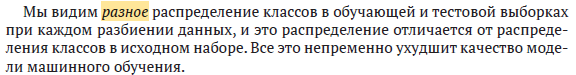

In [15]:
# взглянем на распределение классов в обучающей
# и тестовой выборках по каждой из 3 итераций
for cnt, (train_index, test_index) in enumerate(kfold.split(X, y), 1):
    print(f"\n{cnt}-я итерация")
    uniques, counts = np.unique(y[train_index], return_counts=True)
    train_pcnt = dict(zip(uniques, counts * 100 / len(y[train_index])))
    uniques, counts = np.unique(y[test_index], return_counts=True)
    test_pcnt = dict(zip(uniques, counts * 100 / len(y[test_index])))
    print("\nTRAIN:")
    for k, v in train_pcnt.items():
        print(f"  {k}: {v:.1f}%")  # форматируем с одним знаком после запятой
    print("TEST:")
    for k, v in test_pcnt.items():
        print(f"  {k}: {v:.1f}%")


1-я итерация

TRAIN:
  0: 31.0%
  1: 35.0%
  2: 34.0%
TEST:
  0: 38.0%
  1: 30.0%
  2: 32.0%

2-я итерация

TRAIN:
  0: 32.0%
  1: 33.0%
  2: 35.0%
TEST:
  0: 36.0%
  1: 34.0%
  2: 30.0%

3-я итерация

TRAIN:
  0: 37.0%
  1: 32.0%
  2: 31.0%
TEST:
  0: 26.0%
  1: 36.0%
  2: 38.0%


###cs-training.csv

In [18]:
import urllib.request
urllib.request.urlretrieve(
    'https://github.com/MinyaevAndrey/Data_Preprocessing_in_Python/blob/main/code/Data/cs-training.csv?raw=true',
    'cs-training.csv'
)
# считываем данные
data = pd.read_csv('cs-training.csv', index_col=0)
data.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [17]:
# заменяем пропуски
data.fillna(0, inplace=True)
# создаем массив меток и массив признаков
labels = data.pop('SeriousDlqin2yrs')

In [19]:
# посмотрим количество наблюдений
# и распределение классов
print(len(data))
print("")
print(labels.value_counts(normalize=True))

150000

SeriousDlqin2yrs
0    0.93316
1    0.06684
Name: proportion, dtype: float64


In [20]:
# взглянем на распределение классов в обучающей
# и тестовой выборках по каждой из 3 итераций
for cnt, (train_index, test_index) in enumerate(
    kfold.split(data, labels), 1):
    print(f"\n{cnt}-я итерация")
    train_pcnt = round(labels.iloc[train_index].value_counts(
        normalize=True), 3)
    print(f"\nTRAIN:\n{train_pcnt}\n")
    test_pcnt = round(labels.iloc[test_index].value_counts(
        normalize=True), 3)
    print(f"TEST:\n{test_pcnt}")

# мы видим примерно одинаковое рас-
# пределение классов в обучающем и тестовом блоках при каждом разбиении
# данных.


1-я итерация

TRAIN:
SeriousDlqin2yrs
0    0.933
1    0.067
Name: proportion, dtype: float64

TEST:
SeriousDlqin2yrs
0    0.934
1    0.066
Name: proportion, dtype: float64

2-я итерация

TRAIN:
SeriousDlqin2yrs
0    0.933
1    0.067
Name: proportion, dtype: float64

TEST:
SeriousDlqin2yrs
0    0.933
1    0.067
Name: proportion, dtype: float64

3-я итерация

TRAIN:
SeriousDlqin2yrs
0    0.934
1    0.066
Name: proportion, dtype: float64

TEST:
SeriousDlqin2yrs
0    0.932
1    0.068
Name: proportion, dtype: float64


In [23]:
# создаем экземляр класса DecisionTreeClassifier
tree = DecisionTreeClassifier(random_state=152)

# вычисляем значение правильности, усредненное по тестовым
# выборкам обычной нестратифицированной перекрестной проверки
scores_acc = cross_val_score(tree,
                             data,
                             labels,
                             cv=KFold(n_splits=3, shuffle=True, random_state=42)
)
print("Среднее значение правильности: {:.2f}".format(
    scores_acc.mean()))

Среднее значение правильности: 1.00


## Обычная стратифицированная k-блочная перекрестная проверка с помощью класса StratifiedKFold

In [25]:
# создаем экземпляр класса StratifiedKFold
stratkfold = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# взглянем на распределение классов в обучающей
# и тестовой выборках по каждой из 3 итераций
for cnt, (train_index, test_index) in enumerate(
    stratkfold.split(X, y), 1):
    print(f"\n{cnt}-я итерация")
    uniques, counts = np.unique(y[train_index], return_counts=True)
    train_pcnt = dict(zip(uniques, counts * 100 / len(y[train_index])))
    uniques, counts = np.unique(y[test_index], return_counts=True)
    test_pcnt = dict(zip(uniques, counts * 100 / len(y[test_index])))
    print("\nTRAIN:")
    for k, v in train_pcnt.items():
        print(f"  {k}: {v:.1f}%")  # форматируем с одним знаком после запятой
    print("TEST:")
    for k, v in test_pcnt.items():
        print(f"  {k}: {v:.1f}%")


1-я итерация

TRAIN:
  0: 33.0%
  1: 33.0%
  2: 34.0%
TEST:
  0: 34.0%
  1: 34.0%
  2: 32.0%

2-я итерация

TRAIN:
  0: 33.0%
  1: 34.0%
  2: 33.0%
TEST:
  0: 34.0%
  1: 32.0%
  2: 34.0%

3-я итерация

TRAIN:
  0: 34.0%
  1: 33.0%
  2: 33.0%
TEST:
  0: 32.0%
  1: 34.0%
  2: 34.0%


In [ ]:
# взглянем на распределение классов в обучающей
# и тестовой выборках по каждой из 3 итераций
for cnt, (train_index, test_index) in enumerate(
    stratkfold.split(data, labels), 1):
    print(f"\n{cnt}-я итерация")
    train_pcnt = round(labels.iloc[train_index].value_counts(
        normalize=True), 3)
    print(f"\nTRAIN:\n{train_pcnt}\n")
    test_pcnt = round(labels.iloc[test_index].value_counts(
        normalize=True), 3)
    print(f"TEST:\n{test_pcnt}")


1-я итерация

TRAIN:
0    0.933
1    0.067
Name: SeriousDlqin2yrs, dtype: float64

TEST:
0    0.933
1    0.067
Name: SeriousDlqin2yrs, dtype: float64

2-я итерация

TRAIN:
0    0.933
1    0.067
Name: SeriousDlqin2yrs, dtype: float64

TEST:
0    0.933
1    0.067
Name: SeriousDlqin2yrs, dtype: float64

3-я итерация

TRAIN:
0    0.933
1    0.067
Name: SeriousDlqin2yrs, dtype: float64

TEST:
0    0.933
1    0.067
Name: SeriousDlqin2yrs, dtype: float64


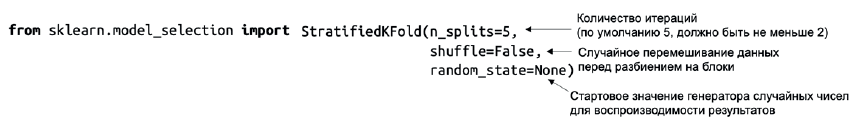

In [27]:
# вычисляем значение правильности, усредненное по тестовым
# выборкам обычной стратифицированной перекрестной проверки
scores_acc = cross_val_score(tree,
                             data,
                             labels,
                             cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
)
print("Среднее значение правильности: {:.2f}".format(
    scores_acc.mean()))

Среднее значение правильности: 1.00


## Повторная нестратифицированная k-блочная перекрестная проверка с помощью класса RepeatedKFold

In [ ]:
# создаем экземпляр класса KFold
kfold = KFold(n_splits=3, shuffle=True, random_state=42)
# взглянем на индексы наблюдений, попавших в обучающую
# и тестовую выборки, по каждой из 3 итераций
for train_index, test_index in kfold.split(X_toy, y_toy):
    print("TRAIN:", train_index, "TEST:", test_index)

TRAIN: [2 3 4 6 7 9] TEST: [0 1 5 8]
TRAIN: [0 1 3 4 5 6 8] TEST: [2 7 9]
TRAIN: [0 1 2 5 7 8 9] TEST: [3 4 6]


In [ ]:
# создаем экземпляр класса RepeatedKFold
rkf = RepeatedKFold(n_splits=3, n_repeats=2, random_state=42)
# взглянем на индексы наблюдений, попавших в обучающую
# и тестовую выборки, по каждой из 2 итераций 2 повторов
for train_index, test_index in rkf.split(X_toy, y_toy):
    print("TRAIN:", train_index, "TEST:", test_index)

TRAIN: [2 3 4 6 7 9] TEST: [0 1 5 8]
TRAIN: [0 1 3 4 5 6 8] TEST: [2 7 9]
TRAIN: [0 1 2 5 7 8 9] TEST: [3 4 6]
TRAIN: [2 3 4 6 7 9] TEST: [0 1 5 8]
TRAIN: [0 1 2 5 6 8 9] TEST: [3 4 7]
TRAIN: [0 1 3 4 5 7 8] TEST: [2 6 9]


In [28]:
# RepeatedKFold = KFold, повторенный несколько раз с РАЗНЫМ разбиением на блоки каждый раз.

# вычисляем значение правильности, усредненное по
# тестовым выборкам повторной нестратифицированной
# перекрестной проверки
scores_acc = cross_val_score(tree,
                             data,
                             labels,
                             cv=RepeatedKFold(n_splits=5, n_repeats=2, random_state=42)
)
print("Среднее значение правильности: {:.2f}".format(
    scores_acc.mean()))

Среднее значение правильности: 1.00


## Повторная стратифицированная k-блочная перекрестная проверка с помощью класса RepeatedStratifiedKFold

In [29]:
# вычисляем значение правильности, усредненное по
# тестовым выборкам повторной стратифицированной
# перекрестной проверки
scores_acc = cross_val_score(tree,
                             data,
                             labels,
                             cv=RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=42)
)
print("Среднее значение правильности: {:.2f}".format(
    scores_acc.mean()))

Среднее значение правильности: 1.00


## k-кратное случайное разбиение на обучающую и тестовую выборки (перекрестная проверка Монте-Карло)

In [ ]:
# пишем функцию, выполняющую перекрестную проверку
# по методу Монте-Карло
def monte_carlo_crossvalidation(estimator,
                                X,
                                y,
                                n_splits=10,
                                test_size=0.3):
    """
    Выполняет перекрестную проверку
    по методу Монте-Карло

    Параметры
    ----------
    estimator: экземпляр класса
        Модель машинного обучения.
    X: pandas.DataFrame
        Массив признаков.
    y: pandas.Series
        Массив меток.
    n_splits: int, по умолчанию 10
        Количество случайных разбиений
        на обучающую и тестовую выборки
    test_size: float, по умолчанию 0.3
        Размер тестовой выборки.
    """
    # создадим пустой список, в которой будем
    # записывать значения правильности
    accuracy_list = []
    # выполняем n_splits раз случайное разбиение на обучающую
    # и тестовую выборки (размер тестовой выборки определяется
    # с помощью test_size) и печатаем значение правильности
    # для обучающей и тестовой выборок в каждой итерации
    for i in range(n_splits):
        train, test, y_train, y_test = train_test_split(
            X,
            y,
            random_state=i,
            test_size=test_size)
        print("train=%d, test=%d" % (len(train), len(test)))
        estimator.fit(train, y_train)
        train_score = estimator.score(train, y_train)
        test_score = estimator.score(test, y_test)
        print("Правильность на обучающей выборке: {:.3f}".format(
            train_score))
        print("Правильность на тестовой выборке: {:.3f}".format(
            test_score))
        print("")
        accuracy_list.append(test_score)
    # печатаем среднее значение правильности
    print("Среднее значение правильности: {:.3f}".format(
        sum(accuracy_list) / len(accuracy_list)))

In [ ]:
# применяем нашу функцию
monte_carlo_crossvalidation(tree,
                            data,
                            labels,
                            n_splits=10,
                            test_size=0.3)

train=105000, test=45000
Правильность на обучающей выборке: 1.000
Правильность на тестовой выборке: 0.896

train=105000, test=45000
Правильность на обучающей выборке: 1.000
Правильность на тестовой выборке: 0.900

train=105000, test=45000
Правильность на обучающей выборке: 1.000
Правильность на тестовой выборке: 0.897

train=105000, test=45000
Правильность на обучающей выборке: 1.000
Правильность на тестовой выборке: 0.900

train=105000, test=45000
Правильность на обучающей выборке: 1.000
Правильность на тестовой выборке: 0.897

train=105000, test=45000
Правильность на обучающей выборке: 1.000
Правильность на тестовой выборке: 0.896

train=105000, test=45000
Правильность на обучающей выборке: 1.000
Правильность на тестовой выборке: 0.898

train=105000, test=45000
Правильность на обучающей выборке: 1.000
Правильность на тестовой выборке: 0.899

train=105000, test=45000
Правильность на обучающей выборке: 1.000
Правильность на тестовой выборке: 0.897

train=105000, test=45000
Правильность

## Перекрестная проверка со случайными перестановками при разбиении с помощью класса ShuffleSplit

In [ ]:
# создаем экземпляр класса ShuffleSplit
shuffle_split = ShuffleSplit(test_size=0.5, train_size=0.5,
                             n_splits=5, random_state=42)
# взглянем на индексы наблюдений, попавших в обучающую
# и тестовую выборки, по каждой из 5 итераций
for train_index, test_index in shuffle_split.split(X_toy, y_toy):
    print("TRAIN:", train_index, "TEST:", test_index)

TRAIN: [2 9 4 3 6] TEST: [8 1 5 0 7]
TRAIN: [4 7 9 6 2] TEST: [0 1 8 5 3]
TRAIN: [5 3 7 1 4] TEST: [9 2 0 6 8]
TRAIN: [0 3 4 5 9] TEST: [1 7 6 2 8]
TRAIN: [7 6 3 2 9] TEST: [1 5 4 8 0]


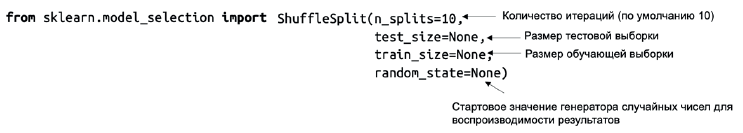

In [30]:
# В перекрестной проверке со случайными перестановками принадлежность наблюдения
# к обучающей или тестовой выборке меняется от разбиения к разбиению

# вычисляем значение правильности, усредненное по
# тестовым выборкам повторной нестратифицированной
# перекрестной проверки
scores_acc = cross_val_score(tree,
                             data,
                             labels,
                             cv=ShuffleSplit(test_size=0.3, train_size=0.7, n_splits=10, random_state=42)
)
print("Среднее значение правильности: {:.2f}".format(
    scores_acc.mean()))

Среднее значение правильности: 1.00


In [ ]:
# создаем экземпляр класса ShuffleSplit
shflsplt = ShuffleSplit(test_size=0.5, train_size=0.5,
                        n_splits=3, random_state=42)

# взглянем на распределение классов в обучающей
# и тестовой выборках по каждой из 3 итераций
for cnt, (train_index, test_index) in enumerate(
    shflsplt.split(X, y), 1):
    print(f"\n{cnt}-я итерация")
    uniques, counts = np.unique(y[train_index], return_counts=True)
    train_pcnt = dict(zip(uniques, counts * 100 / len(y[train_index])))
    uniques, counts = np.unique(y[test_index], return_counts=True)
    test_pcnt = dict(zip(uniques, counts * 100 / len(y[test_index])))
    print("\nTRAIN:\n", train_pcnt)
    print("TEST:\n", test_pcnt)


1-я итерация

TRAIN:
 {0: 28.0, 1: 36.0, 2: 36.0}
TEST:
 {0: 38.666666666666664, 1: 30.666666666666668, 2: 30.666666666666668}

2-я итерация

TRAIN:
 {0: 26.666666666666668, 1: 36.0, 2: 37.333333333333336}
TEST:
 {0: 40.0, 1: 30.666666666666668, 2: 29.333333333333332}

3-я итерация

TRAIN:
 {0: 36.0, 1: 26.666666666666668, 2: 37.333333333333336}
TEST:
 {0: 30.666666666666668, 1: 40.0, 2: 29.333333333333332}


## Стратифицированная перекрестная проверка со случайными перестановками при разбиении с помощью класса  StratifiedShuffleSplit

In [ ]:
# создаем экземпляр класса StratifiedShuffleSplit
stratshflsplt = StratifiedShuffleSplit(
    test_size=0.5, train_size=0.5,
    n_splits=3, random_state=42)

# взглянем на распределение классов в обучающей
# и тестовой выборках по каждой из 3 итераций
for cnt, (train_index, test_index) in enumerate(
    stratshflsplt.split(X, y), 1):
    print(f"\n{cnt}-я итерация")
    uniques, counts = np.unique(y[train_index], return_counts=True)
    train_pcnt = dict(zip(uniques, counts * 100 / len(y[train_index])))
    uniques, counts = np.unique(y[test_index], return_counts=True)
    test_pcnt = dict(zip(uniques, counts * 100 / len(y[test_index])))
    print("\nTRAIN:\n", train_pcnt)
    print("TEST:\n", test_pcnt)


1-я итерация

TRAIN:
 {0: 33.333333333333336, 1: 33.333333333333336, 2: 33.333333333333336}
TEST:
 {0: 33.333333333333336, 1: 33.333333333333336, 2: 33.333333333333336}

2-я итерация

TRAIN:
 {0: 33.333333333333336, 1: 33.333333333333336, 2: 33.333333333333336}
TEST:
 {0: 33.333333333333336, 1: 33.333333333333336, 2: 33.333333333333336}

3-я итерация

TRAIN:
 {0: 33.333333333333336, 1: 33.333333333333336, 2: 33.333333333333336}
TEST:
 {0: 33.333333333333336, 1: 33.333333333333336, 2: 33.333333333333336}


## Перекрестная проверка с исключением по одному с помощью класса LeaveOneOut

In [ ]:
# создаем экземпляр класса LeaveOneOut
loo = LeaveOneOut()

# взглянем на индексы наблюдений, попавших в обучающую
# и тестовую выборки, по каждой итерации,
# количество итераций = количество наблюдений
for train_index, test_index in loo.split(X_toy, y_toy):
    print("TRAIN:", train_index, "TEST:", test_index)

TRAIN: [1 2 3 4 5 6 7 8 9] TEST: [0]
TRAIN: [0 2 3 4 5 6 7 8 9] TEST: [1]
TRAIN: [0 1 3 4 5 6 7 8 9] TEST: [2]
TRAIN: [0 1 2 4 5 6 7 8 9] TEST: [3]
TRAIN: [0 1 2 3 5 6 7 8 9] TEST: [4]
TRAIN: [0 1 2 3 4 6 7 8 9] TEST: [5]
TRAIN: [0 1 2 3 4 5 7 8 9] TEST: [6]
TRAIN: [0 1 2 3 4 5 6 8 9] TEST: [7]
TRAIN: [0 1 2 3 4 5 6 7 9] TEST: [8]
TRAIN: [0 1 2 3 4 5 6 7 8] TEST: [9]


In [ ]:
# записываем CSV-файл в объект DataFrame
data = pd.read_csv('Data/Bankloan.csv',
                   sep=';', decimal=',')

# создаем массив меток и массив признаков
y = data.pop('default')
X = pd.get_dummies(data)

# печатаем количество наблюдений
print(len(X))

# вычисляем значение правильности, усредненное по тестовым
# блокам перекрестной проверки c исключением по одному
scores_acc = cross_val_score(tree,
                             X,
                             y,
                             cv=LeaveOneOut()
)
print("Количество итераций cv: ", len(scores_acc))
print("Среднее значение правильности: {:.2f}".format(
    scores_acc.mean()))

1500
Количество итераций cv:  1500
Среднее значение правильности: 0.65


## Перекрестная проверка с исключением p наблюдений с помощью класса LeavePOut

In [ ]:
# создаем экземпляр класса LeavePOut
lpo = LeavePOut(2)

# взглянем на индексы наблюдений, попавших в обучающую
# и тестовую выборки, по каждой итерации
for cnt, (train_index, test_index) in enumerate(
    lpo.split(X_toy, y_toy), 1):
    print(f"\n{cnt}-я итерация")
    print("TRAIN:", train_index, "TEST:", test_index)


1-я итерация
TRAIN: [2 3 4 5 6 7 8 9] TEST: [0 1]

2-я итерация
TRAIN: [1 3 4 5 6 7 8 9] TEST: [0 2]

3-я итерация
TRAIN: [1 2 4 5 6 7 8 9] TEST: [0 3]

4-я итерация
TRAIN: [1 2 3 5 6 7 8 9] TEST: [0 4]

5-я итерация
TRAIN: [1 2 3 4 6 7 8 9] TEST: [0 5]

6-я итерация
TRAIN: [1 2 3 4 5 7 8 9] TEST: [0 6]

7-я итерация
TRAIN: [1 2 3 4 5 6 8 9] TEST: [0 7]

8-я итерация
TRAIN: [1 2 3 4 5 6 7 9] TEST: [0 8]

9-я итерация
TRAIN: [1 2 3 4 5 6 7 8] TEST: [0 9]

10-я итерация
TRAIN: [0 3 4 5 6 7 8 9] TEST: [1 2]

11-я итерация
TRAIN: [0 2 4 5 6 7 8 9] TEST: [1 3]

12-я итерация
TRAIN: [0 2 3 5 6 7 8 9] TEST: [1 4]

13-я итерация
TRAIN: [0 2 3 4 6 7 8 9] TEST: [1 5]

14-я итерация
TRAIN: [0 2 3 4 5 7 8 9] TEST: [1 6]

15-я итерация
TRAIN: [0 2 3 4 5 6 8 9] TEST: [1 7]

16-я итерация
TRAIN: [0 2 3 4 5 6 7 9] TEST: [1 8]

17-я итерация
TRAIN: [0 2 3 4 5 6 7 8] TEST: [1 9]

18-я итерация
TRAIN: [0 1 4 5 6 7 8 9] TEST: [2 3]

19-я итерация
TRAIN: [0 1 3 5 6 7 8 9] TEST: [2 4]

20-я итерация
TRAIN:

In [ ]:
# создаем игрушечные массив признаков и массив меток
X_toy = np.array([0.1, 0.2, 2.2, 2.4, 2.3,
                  4.55, 5.8, 8.8, 9, 10])
y_toy = np.array([0, 0, 0, 1, 1, 1, 0, 0, 0, 0])
# создаем идентификатор групп
groups = np.array([1, 1, 1, 2, 2, 2, 3, 3, 3, 3])

# Виды перекрестной проверки для данных формата «один клиент – несколько наблюдений» и стратифицированных данных (отсутствует ось времени)

## Перекрестная проверка, учитывающая группы связанных наблюдений, с помощью классов GroupKFold

In [ ]:
# создаем экземпляр класса GroupKFold
gkf = GroupKFold(n_splits=3)

# взглянем на индексы групп, попавших в обучающую
# и тестовую выборки, по каждой из 3 итераций
for train, test in gkf.split(X_toy, y_toy, groups=groups):
    print("TRAIN:", groups[train], "TEST:", groups[test])

TRAIN: [1 1 1 2 2 2] TEST: [3 3 3 3]
TRAIN: [1 1 1 3 3 3 3] TEST: [2 2 2]
TRAIN: [2 2 2 3 3 3 3] TEST: [1 1 1]


In [ ]:
# создаем игрушечные массив признаков и массив меток
X_toy = np.array(list(range(17)))
y_toy = np.array([0, 0, 1, 1, 1, 1, 1, 1, 0,
                  0, 0, 0, 0, 0, 0, 0, 0])
# создаем идентификатор групп
groups = np.array([1, 1, 2, 2, 3, 3, 3, 4, 5,
                   5, 5, 5, 6, 6, 7, 8, 8])

In [ ]:
# взглянем на индексы групп, попавших в обучающую
# и тестовую выборки, по каждой из 3 итераций
for train, test in gkf.split(X_toy, y_toy, groups=groups):
    print("TRAIN:", groups[train], "TEST:", groups[test])

TRAIN: [2 2 3 3 3 4 6 6 7 8 8] TEST: [1 1 5 5 5 5]
TRAIN: [1 1 5 5 5 5 6 6 7 8 8] TEST: [2 2 3 3 3 4]
TRAIN: [1 1 2 2 3 3 3 4 5 5 5 5] TEST: [6 6 7 8 8]


## Перекрестная проверка, учитывающая группы связанных наблюдений с исключением из обучения одной группы, с помощью класса LeaveOneGroupOut

In [ ]:
# создаем экземпляр класса LeaveOneGroupOut
logo = LeaveOneGroupOut()

# взглянем на индексы групп, попавших в обучающую
# и тестовую выборки, по каждой из 8 итераций,
# количество итераций=количество групп
for train, test in logo.split(X_toy, y_toy, groups=groups):
    print("TRAIN:", groups[train], "TEST:", groups[test])

TRAIN: [2 2 3 3 3 4 5 5 5 5 6 6 7 8 8] TEST: [1 1]
TRAIN: [1 1 3 3 3 4 5 5 5 5 6 6 7 8 8] TEST: [2 2]
TRAIN: [1 1 2 2 4 5 5 5 5 6 6 7 8 8] TEST: [3 3 3]
TRAIN: [1 1 2 2 3 3 3 5 5 5 5 6 6 7 8 8] TEST: [4]
TRAIN: [1 1 2 2 3 3 3 4 6 6 7 8 8] TEST: [5 5 5 5]
TRAIN: [1 1 2 2 3 3 3 4 5 5 5 5 7 8 8] TEST: [6 6]
TRAIN: [1 1 2 2 3 3 3 4 5 5 5 5 6 6 8 8] TEST: [7]
TRAIN: [1 1 2 2 3 3 3 4 5 5 5 5 6 6 7] TEST: [8 8]


In [ ]:
# создаем экземпляр класса GroupKFold
new_gkf = GroupKFold(n_splits=8)

# взглянем на индексы групп, попавших в обучающую
# и тестовую выборки, по каждой из 8 итераций
for train, test in new_gkf.split(X_toy, y_toy, groups=groups):
    print("TRAIN:", groups[train], "TEST:", groups[test])

TRAIN: [1 1 2 2 3 3 3 4 6 6 7 8 8] TEST: [5 5 5 5]
TRAIN: [1 1 2 2 4 5 5 5 5 6 6 7 8 8] TEST: [3 3 3]
TRAIN: [1 1 2 2 3 3 3 4 5 5 5 5 6 6 7] TEST: [8 8]
TRAIN: [1 1 2 2 3 3 3 4 5 5 5 5 7 8 8] TEST: [6 6]
TRAIN: [1 1 3 3 3 4 5 5 5 5 6 6 7 8 8] TEST: [2 2]
TRAIN: [2 2 3 3 3 4 5 5 5 5 6 6 7 8 8] TEST: [1 1]
TRAIN: [1 1 2 2 3 3 3 4 5 5 5 5 6 6 8 8] TEST: [7]
TRAIN: [1 1 2 2 3 3 3 5 5 5 5 6 6 7 8 8] TEST: [4]


## Перекрестная проверка, учитывающая группы связанных наблюдений с исключением из обучения p групп, с помощью класса LeavePGroupsOut

In [ ]:
# создаем экземпляр класса LeavePGroupsOut
lpgo = LeavePGroupsOut(n_groups=2)

# взглянем на индексы групп, попавших в обучающую
# и тестовую выборки, по каждой из 28 итераций
for cnt, (train, test) in enumerate(
    lpgo.split(X_toy, y_toy, groups=groups), 1):
    print(f"\n{cnt}-я итерация")
    print("TRAIN:", groups[train], "TEST:", groups[test])


1-я итерация
TRAIN: [3 3 3 4 5 5 5 5 6 6 7 8 8] TEST: [1 1 2 2]

2-я итерация
TRAIN: [2 2 4 5 5 5 5 6 6 7 8 8] TEST: [1 1 3 3 3]

3-я итерация
TRAIN: [2 2 3 3 3 5 5 5 5 6 6 7 8 8] TEST: [1 1 4]

4-я итерация
TRAIN: [2 2 3 3 3 4 6 6 7 8 8] TEST: [1 1 5 5 5 5]

5-я итерация
TRAIN: [2 2 3 3 3 4 5 5 5 5 7 8 8] TEST: [1 1 6 6]

6-я итерация
TRAIN: [2 2 3 3 3 4 5 5 5 5 6 6 8 8] TEST: [1 1 7]

7-я итерация
TRAIN: [2 2 3 3 3 4 5 5 5 5 6 6 7] TEST: [1 1 8 8]

8-я итерация
TRAIN: [1 1 4 5 5 5 5 6 6 7 8 8] TEST: [2 2 3 3 3]

9-я итерация
TRAIN: [1 1 3 3 3 5 5 5 5 6 6 7 8 8] TEST: [2 2 4]

10-я итерация
TRAIN: [1 1 3 3 3 4 6 6 7 8 8] TEST: [2 2 5 5 5 5]

11-я итерация
TRAIN: [1 1 3 3 3 4 5 5 5 5 7 8 8] TEST: [2 2 6 6]

12-я итерация
TRAIN: [1 1 3 3 3 4 5 5 5 5 6 6 8 8] TEST: [2 2 7]

13-я итерация
TRAIN: [1 1 3 3 3 4 5 5 5 5 6 6 7] TEST: [2 2 8 8]

14-я итерация
TRAIN: [1 1 2 2 5 5 5 5 6 6 7 8 8] TEST: [3 3 3 4]

15-я итерация
TRAIN: [1 1 2 2 4 6 6 7 8 8] TEST: [3 3 3 5 5 5 5]

16-я итерация
TRAI

## Перекрестная проверка, учитывающая группы связанных наблюдений и распределение классов, с помощью класса StratifiedGroupKFold

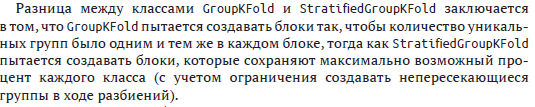

In [ ]:
# взглянем на распределение классов, индексы групп
# и значения зависимой переменной в обучающей
# и тестовой выборках по каждой из 3 итераций
for cnt, (train, test) in enumerate(
    gkf.split(X_toy, y_toy, groups=groups), 1):
    print(f"\n{cnt}-я итерация")
    uniques, counts = np.unique(y_toy[train], return_counts=True)
    train_pcnt = dict(zip(uniques, counts * 100 / len(y_toy[train])))
    uniques, counts = np.unique(y_toy[test], return_counts=True)
    test_pcnt = dict(zip(uniques, counts * 100 / len(y_toy[test])))
    print("\nTRAIN:\n", train_pcnt)
    print(" groups:", groups[train])
    print("      y:", y_toy[train])
    print("TEST:\n", test_pcnt)
    print(" groups:", groups[test])
    print("      y:", y_toy[test])


1-я итерация

TRAIN:
 {0: 45.45454545454545, 1: 54.54545454545455}
 groups: [2 2 3 3 3 4 6 6 7 8 8]
      y: [1 1 1 1 1 1 0 0 0 0 0]
TEST:
 {0: 100.0}
 groups: [1 1 5 5 5 5]
      y: [0 0 0 0 0 0]

2-я итерация

TRAIN:
 {0: 100.0}
 groups: [1 1 5 5 5 5 6 6 7 8 8]
      y: [0 0 0 0 0 0 0 0 0 0 0]
TEST:
 {1: 100.0}
 groups: [2 2 3 3 3 4]
      y: [1 1 1 1 1 1]

3-я итерация

TRAIN:
 {0: 50.0, 1: 50.0}
 groups: [1 1 2 2 3 3 3 4 5 5 5 5]
      y: [0 0 1 1 1 1 1 1 0 0 0 0]
TEST:
 {0: 100.0}
 groups: [6 6 7 8 8]
      y: [0 0 0 0 0]


In [ ]:
# создаем экземпляр класса StratifiedGroupKFold
sgkf = StratifiedGroupKFold(n_splits=3)

# взглянем на индексы наблюдений, попавших в обучающую
# и тестовую выборки, по каждой из 3 итераций
for cnt, (train, test) in enumerate(
    sgkf.split(X_toy, y_toy, groups=groups), 1):
    print(f"\n{cnt}-я итерация")
    uniques, counts = np.unique(y_toy[train], return_counts=True)
    train_pcnt = dict(zip(uniques, counts * 100 / len(y[train])))
    uniques, counts = np.unique(y_toy[test], return_counts=True)
    test_pcnt = dict(zip(uniques, counts * 100 / len(y[test])))
    print("\nTRAIN:\n", train_pcnt)
    print(" groups:", groups[train])
    print("      y:", y_toy[train])
    print("TEST:\n", test_pcnt)
    print(" groups:", groups[test])
    print("      y:", y_toy[test])


1-я итерация

TRAIN:
 {0: 72.72727272727273, 1: 27.272727272727273}
 groups: [1 1 2 2 4 5 5 5 5 8 8]
      y: [0 0 1 1 1 0 0 0 0 0 0]
TEST:
 {0: 50.0, 1: 50.0}
 groups: [3 3 3 6 6 7]
      y: [1 1 1 0 0 0]

2-я итерация

TRAIN:
 {0: 63.63636363636363, 1: 36.36363636363637}
 groups: [3 3 3 4 5 5 5 5 6 6 7]
      y: [1 1 1 1 0 0 0 0 0 0 0]
TEST:
 {0: 66.66666666666667, 1: 33.333333333333336}
 groups: [1 1 2 2 8 8]
      y: [0 0 1 1 0 0]

3-я итерация

TRAIN:
 {0: 58.333333333333336, 1: 41.666666666666664}
 groups: [1 1 2 2 3 3 3 6 6 7 8 8]
      y: [0 0 1 1 1 1 1 0 0 0 0 0]
TEST:
 {0: 80.0, 1: 20.0}
 groups: [4 5 5 5 5]
      y: [1 0 0 0 0]


## Перекрестная проверка со случайными перестановками при разбиении и учитывающая группы связанных наблюдений с помощью класса GroupShuffleSplit

In [ ]:
# создаем экземпляр класса GroupShuffleSplit
grpshflsplt = GroupShuffleSplit(train_size=6,
                                test_size=2,
                                n_splits=5,
                                random_state=42)

# взглянем на индексы групп, попавших в обучающую
# и тестовую выборки
for cnt, (train, test) in enumerate(
    grpshflsplt.split(X_toy, y_toy, groups=groups), 1):
    print(f"\n{cnt}-я итерация")
    print("TRAIN:", groups[train], "TEST:", groups[test])


1-я итерация
TRAIN: [1 1 3 3 3 4 5 5 5 5 7 8 8] TEST: [2 2 6 6]

2-я итерация
TRAIN: [1 1 2 2 3 3 3 5 5 5 5 6 6 7] TEST: [4 8 8]

3-я итерация
TRAIN: [2 2 3 3 3 4 5 5 5 5 6 6 8 8] TEST: [1 1 7]

4-я итерация
TRAIN: [1 1 2 2 4 5 5 5 5 7 8 8] TEST: [3 3 3 6 6]

5-я итерация
TRAIN: [1 1 3 3 3 4 5 5 5 5 6 6 7] TEST: [2 2 8 8]


In [ ]:
# создаем экземпляр класса GroupShuffleSplit
grpshflsplt = GroupShuffleSplit(train_size=0.5,
                                test_size=0.5,
                                n_splits=5,
                                random_state=42)

# взглянем на индексы групп, попавших в обучающую
# и тестовую выборки
for cnt, (train, test) in enumerate(
    grpshflsplt.split(X_toy, y_toy, groups=groups), 1):
    print(f"\n{cnt}-я итерация")
    print("TRAIN:", groups[train], "TEST:", groups[test])


1-я итерация
TRAIN: [3 3 3 4 5 5 5 5 7] TEST: [1 1 2 2 6 6 8 8]

2-я итерация
TRAIN: [2 2 3 3 3 6 6 7] TEST: [1 1 4 5 5 5 5 8 8]

3-я итерация
TRAIN: [3 3 3 5 5 5 5 6 6 8 8] TEST: [1 1 2 2 4 7]

4-я итерация
TRAIN: [1 1 2 2 4 5 5 5 5] TEST: [3 3 3 6 6 7 8 8]

5-я итерация
TRAIN: [1 1 4 5 5 5 5 6 6] TEST: [2 2 3 3 3 7 8 8]
